<a href="https://colab.research.google.com/github/rautsarvesh001/CSL701-CS45-Machine-Learning-Lab/blob/main/EXPERIMENTS/EXPERIMENT_NO_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SARVESH SUNIL RAUT

CS45

EXPERIMENT NO.02

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


Task 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Task 2 — Load Auto MPG Dataset

In [4]:
df = pd.read_csv('/content/auto-mpg.csv')

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


Task 3 — Inspect and Clean Data

In [5]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())
# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert horsepower and mpg to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['mpg'] = pd.to_numeric(df['mpg'], errors='coerce')

# Remove rows with missing values
df = df.dropna(subset=['horsepower', 'mpg'])

print("Shape after cleaning:", df.shape)

Shape of dataset:
(398, 9)

Column names:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtyp

Task 4 — Select Horsepower and MPG

In [6]:
X = df['horsepower'].to_numpy(dtype=float)
y = df['mpg'].to_numpy(dtype=float)

print("Horsepower:")
print(X[:10])

print("\nMPG:")
print(y[:10])

Horsepower:
[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]

MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


Task 5 — Plot Scatter Graph

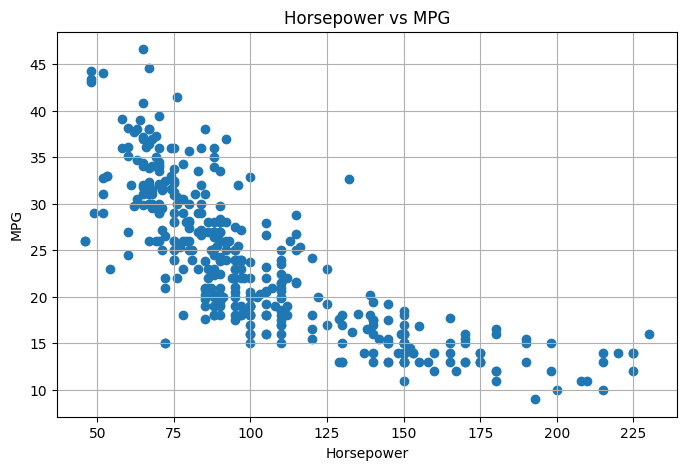

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')

plt.grid(True)
plt.show()

Task 6 — Add Bias Term

In [8]:
X_bias = np.column_stack((np.ones(len(X)), X))

print("X matrix with bias term:")
print(X_bias[:5])

X matrix with bias term:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


Task 7 — Compute Correlation

In [9]:
correlation = np.corrcoef(X, y)[0, 1]

print("Correlation coefficient =", correlation)

Correlation coefficient = -0.7784267838977756


Task 8 — Calculate OLS Weights

In [10]:
beta = np.linalg.solve(
    X_bias.T @ X_bias,
    X_bias.T @ y
)

print("OLS Weights:")
print(beta)

print("Intercept (β0) =", beta[0])
print("Slope (β1) =", beta[1])

OLS Weights:
[39.93586102 -0.15784473]
Intercept (β0) = 39.935861021170574
Slope (β1) = -0.1578447333536545


Task 9 — Predict Values

In [11]:
y_pred = X_bias @ beta

print("First 10 actual MPG values:")
print(y[:10])

print("\nFirst 10 predicted MPG values:")
print(y_pred[:10])

First 10 actual MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


Task 10 — Compute Residuals

In [12]:
residuals = y - y_pred

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Task 11 — Calculate SSE, MSE and R²

In [14]:
SSE = np.sum(residuals ** 2)

print("SSE =", SSE)

MSE = np.mean(residuals ** 2)

print("MSE =", MSE)

SST = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SST)

print("R² =", R2)

SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


Task 12 — Plot Regression and Residual Graphs

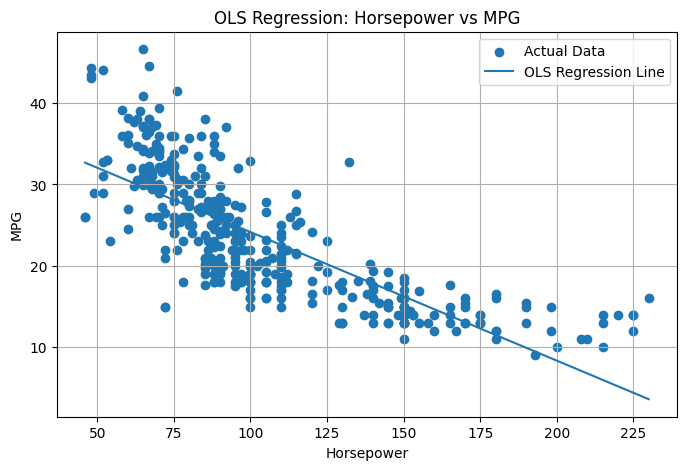

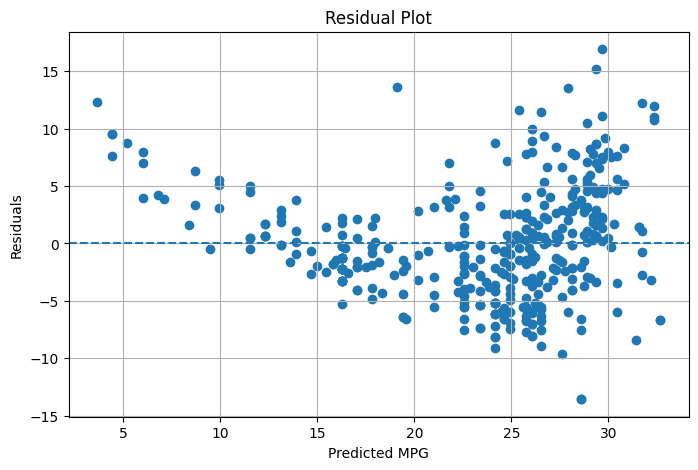

In [15]:
sort_index = np.argsort(X)

X_sorted = X[sort_index]
y_pred_sorted = y_pred[sort_index]

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label='Actual Data')

plt.plot(
    X_sorted,
    y_pred_sorted,
    label='OLS Regression Line'
)

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('OLS Regression: Horsepower vs MPG')

plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.grid(True)
plt.show()

Task 13 — Interpret Results

Interpretation

The scatter plot shows a negative relationship between horsepower and MPG. As the horsepower of a vehicle increases, its MPG generally decreases.

The correlation coefficient is negative, which confirms the inverse relationship between horsepower and MPG.

The OLS regression model calculates the intercept and slope and provides a linear equation for predicting MPG from horsepower.

The R² value indicates how much of the variation in MPG can be explained by horsepower. A higher R² indicates a better fit of the linear regression model.

The residual plot shows the difference between actual and predicted MPG. Residuals distributed around zero indicate that the linear regression model provides a reasonable fit.

Conclusion

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.

